In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dfm=pd.read_csv(r"C:\Users\SANDESH\Downloads\sales_dataset_day6.csv")

In [3]:
df=dfm.copy()

In [4]:
df.head()

,Date,Product,Category,Sales,Quantity
0,2026-01-01,Laptop,Electronics,55000,5
1,2026-01-02,Mouse,Accessories,1200,24
2,2026-01-03,Keyboard,Accessories,2500,10
3,2026-01-04,Laptop,Electronics,60000,6
4,2026-01-05,Monitor,Electronics,18000,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      10 non-null     object
 1   Product   10 non-null     object
 2   Category  10 non-null     object
 3   Sales     10 non-null     int64 
 4   Quantity  10 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 532.0+ bytes


In [16]:
df.describe()

,Date,Sales,Quantity
count,10,10.000000,10.000000
mean,2026-01-05 12:00:00,22060.000000,12.900000
min,2026-01-01 00:00:00,1200.000000,4.000000
25%,2026-01-03 06:00:00,1900.000000,5.000000
50%,2026-01-05 12:00:00,10350.000000,8.000000
75%,2026-01-07 18:00:00,46250.000000,21.000000
max,2026-01-10 00:00:00,60000.000000,30.000000
std,NaN,25531.427257,10.365005


In [7]:
df.shape

(10, 5)

In [8]:
df.columns

Index(['Date', 'Product', 'Category', 'Sales', 'Quantity'], dtype='object')

In [11]:
print(df.isnull().sum())

Date        0
Product     0
Category    0
Sales       0
Quantity    0
dtype: int64


In [12]:
print(df.duplicated().sum())

0


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
df["Sales"] = df["Sales"].astype(float)

In [15]:
df.dtypes

Date        datetime64[ns]
Product             object
Category            object
Sales              float64
Quantity             int64
dtype: object

### Find Revenue

In [17]:
df["Revenue_Per_Item"] = df["Sales"] / df["Quantity"]

In [20]:
high_sales = df[df["Sales"] > 50000]

print(high_sales)

        Date Product     Category    Sales  Quantity  Revenue_Per_Item
3 2026-01-04  Laptop  Electronics  60000.0         6           10000.0
8 2026-01-09  Laptop  Electronics  58000.0         5           11600.0
0 2026-01-01  Laptop  Electronics  55000.0         5           11000.0


In [21]:
df = df.sort_values(by="Sales", ascending=False)

print(df.head())

        Date  Product     Category    Sales  Quantity  Revenue_Per_Item
3 2026-01-04   Laptop  Electronics  60000.0         6           10000.0
8 2026-01-09   Laptop  Electronics  58000.0         5           11600.0
0 2026-01-01   Laptop  Electronics  55000.0         5           11000.0
7 2026-01-08  Monitor  Electronics  20000.0         5            4000.0
4 2026-01-05  Monitor  Electronics  18000.0         4            4500.0


### Group By Analysis

In [22]:
product_sales = df.groupby("Product")["Sales"].sum()

print(product_sales)

Product
Keyboard      5200.0
Laptop      173000.0
Monitor      38000.0
Mouse         4400.0
Name: Sales, dtype: float64


### Visualization

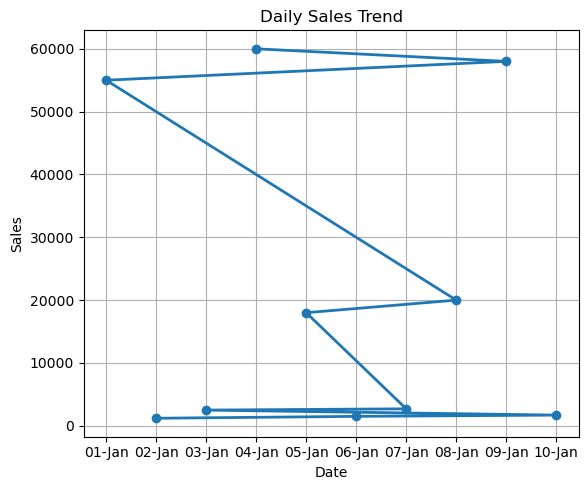

In [34]:

import matplotlib.dates as mdates

plt.figure(figsize=(6,5))

plt.plot(df["Date"], df["Sales"],
         marker="o",
         linewidth=2)

ax = plt.gca()

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d-%b")
)


plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.tight_layout()
plt.show()

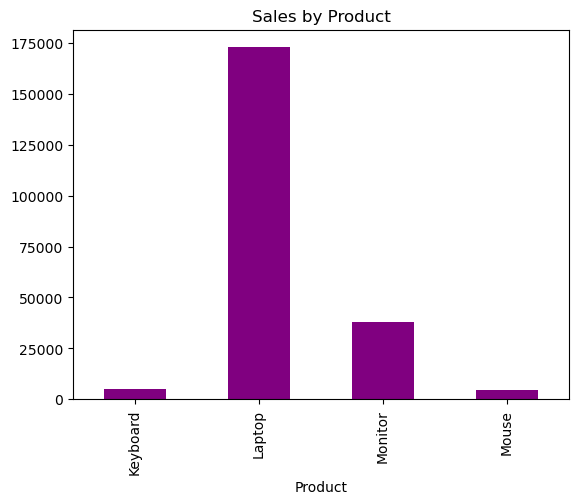

In [46]:
product_sales = df.groupby("Product")["Sales"].sum()

product_sales.plot(kind="bar",color="Purple",width=0.5)

plt.title("Sales by Product")


plt.show()

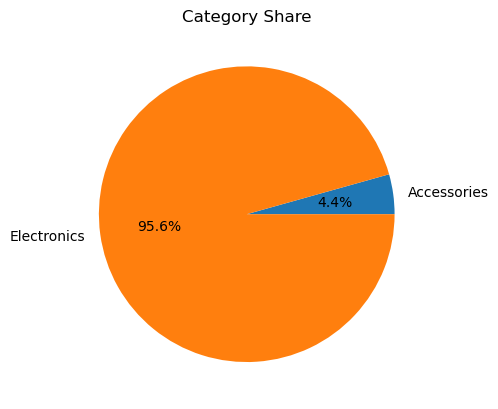

In [49]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.pie(category_sales,
        labels=category_sales.index,
        autopct="%1.1f%%")



plt.title("Category Share")

plt.show()

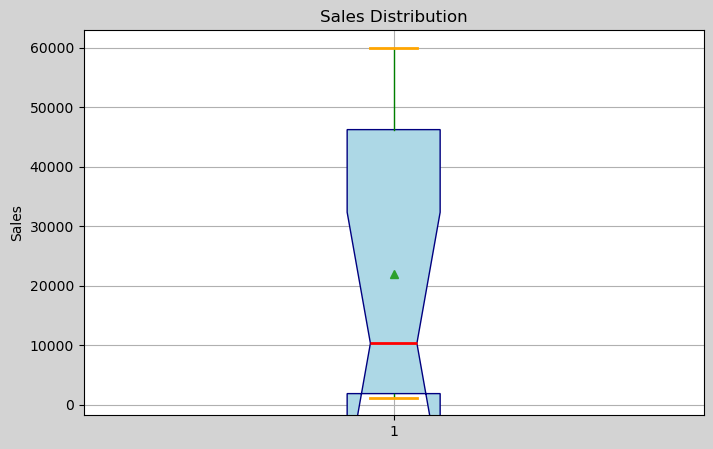

In [73]:


plt.figure(figsize=(8,5),facecolor='lightgray')

plt.boxplot(
    df["Sales"],
    showmeans=True,      # Show mean
    notch=True,          # Show notch around median
    medianprops=dict(color="red", linewidth=2),
    boxprops=dict(facecolor="lightblue",color="navy"),
    whiskerprops=dict(color="green"),
    capprops=dict(color="orange",linewidth=2),
    patch_artist=True,
    


)


plt.title("Sales Distribution")
plt.ylabel("Sales")
plt.grid()

plt.show()

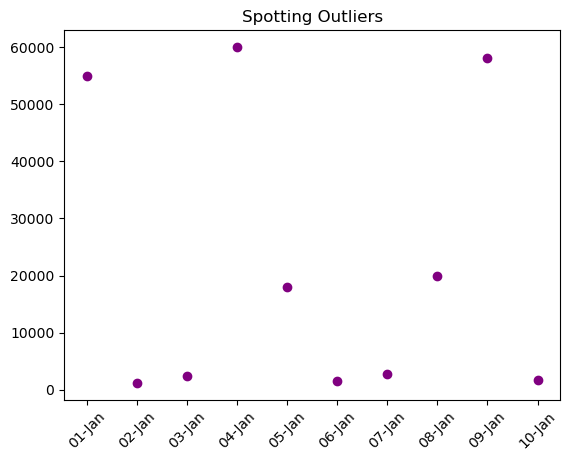

In [78]:
plt.scatter(df["Date"], df["Sales"],color="purple")
plt.xticks(rotation=45)

ax = plt.gca()

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d-%b")
)


plt.title("Spotting Outliers")
plt.show()

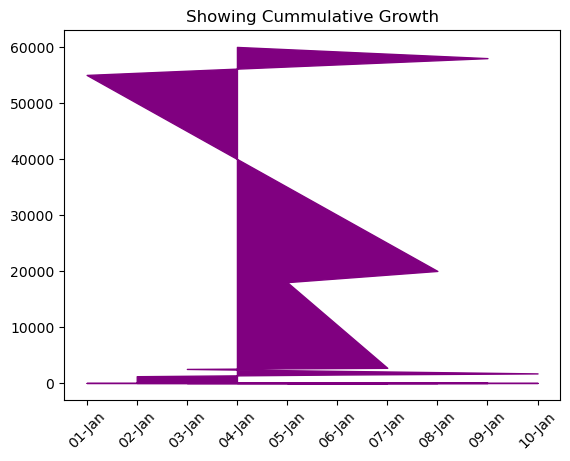

In [82]:
plt.fill_between(df["Date"], df["Sales"],color='purple')
plt.xticks(rotation=45
          )

ax = plt.gca()

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d-%b")
)
plt.title("Showing Cummulative Growth")
plt.show()

In [86]:
df.to_csv("Sales Cleaned05.csv",index=False)
print("Saved Successfully")

Saved Successfully
